# Тема проекта: Мина Лой: анализ прозы и лирики с помощью Стилеметрических признаков.

## Команда №49: Морозова(БФИЛЛ234), Братковская(БФИЛЛ234), Кулагина(БФИЛЛ234)

## ОПИСАНИЕ ДАННЫХ
Мы рассматриваем такие признаки: название, год, тип текста (проза/лирика), сам текст, количество слов, количество предложений, средняя длина предложения, средняя длина слова, доля уникальных слов, доля существительных, доля глаголов, доля прилагательных, доля наречий, доля стоп-слов, доля знаков препинания, доля слов (которые встречаются только один раз), индекс читаемости Флеша, уровень образования для прочтения, индекс туманности Ганнинга, разные индексы тональности, страну написания, период (1 мировая, межвоенный, 2 мировая, послевоенный) и название сборника.

Датасет представляет собой корпус художественных текстов (фрагментов прозаических и лирических произведений), написанных в XX веке Миной Лой. Для каждого текстового фрагмента были автоматически извлечены лингвистические, стилистические и семантические признаки с использованием библиотек spaCy, NLTK, textstat и модуля анализа тональности VADER. Наблюдением в датасете является один текстовый фрагмент из художественного произведения. Датасет был составлен нами самостоятельно: тексты мы вводили вручную и анализировали их с помощью собственного кода на Python.
Количество наблюдений: 137
Количество признаков: 27

## ОПИСАНИЕ ПРИЗНАКОВ

| Признак | Описание | Формат данных | Тип данных |
|----------|----------|---------------|------------|
| title | Название художественного произведения | object | категориальный (номинальный) |
| year | Год написания произведения | float64 | количественный (дискретный) |
| form | Форма текста (проза или лирика) | object | категориальный (бинарный) |
| text | Текстовый фрагмент художественного произведения | object | текстовый |
| word_count | Общее количество слов в тексте | int64 | количественный (дискретный) |
| sentence_count | Количество предложений в тексте | int64 | количественный (дискретный) |
| avg_sentence_length | Средняя длина предложения (в словах) | float64 | количественный (непрерывный) |
| avg_word_length | Средняя длина слова (в символах) | float64 | количественный (непрерывный) |
| unique_words_ratio | Доля уникальных слов от общего количества слов | float64 | количественный (непрерывный) |
| noun_ratio | Доля существительных в тексте | float64 | количественный (непрерывный) |
| verb_ratio | Доля глаголов в тексте | float64 | количественный (непрерывный) |
| adj_ratio | Доля прилагательных в тексте | float64 | количественный (непрерывный) |
| adv_ratio | Доля наречий в тексте | float64 | количественный (непрерывный) |
| stopword_ratio | Доля стоп-слов в тексте | float64 | количественный (непрерывный) |
| punctuation_ratio | Доля знаков препинания от общего числа токенов | float64 | количественный (непрерывный) |
| long_words_ratio | Доля длинных слов (более 7 символов) | float64 | количественный (непрерывный) |
| rare_words_ratio | Доля слов, встречающихся только один раз | float64 | количественный (непрерывный) |
| flesch_reading_ease | Индекс удобочитаемости Флеша (чем выше, тем проще текст) | float64 | количественный (непрерывный) |
| flesch_kincaid_grade | Уровень образования, необходимый для понимания текста | float64 | количественный (непрерывный) |
| gunning_fog | Индекс туманности Ганнинга (сложность текста) | float64 | количественный (непрерывный) |
| sentiment_neg | Доля негативной тональности | float64 | количественный (непрерывный) |
| sentiment_neu | Доля нейтральной тональности | float64 | количественный (непрерывный) |
| sentiment_pos | Доля позитивной тональности | float64 | количественный (непрерывный) |
| sentiment_compound | Агрегированная оценка общей тональности | float64 | количественный (непрерывный) |
| historical_period | Исторический период написания произведения | object | категориальный (номинальный) |
| country_where_written | Страна написания произведения | object | категориальный (номинальный) |
| source | Название сборника или источника текста | object | категориальный (номинальный) |

In [4]:
import pandas as pd
df = pd.read_csv(r'MinaFinalDataset.csv') 
#r перед строкой = "не обрабатывай \ как специальные символы". 
#Он нам здесь не нужен, это из-за Саши говно

## ПРОПУСКИ

In [5]:
#Проверка количества пропусков в данных
missing_values = df.isna().sum()
#df.isna() является ли значение пропущенным
#True → значение пропущено
#False → значение есть
print("Количество пропусков в каждом столбце:")
print(missing_values)

Количество пропусков в каждом столбце:
title                     0
year                     14
form                      0
text                      0
word_count                0
sentence_count            0
avg_sentence_length       0
avg_word_length           0
unique_words_ratio        0
noun_ratio                0
verb_ratio                0
adj_ratio                 0
adv_ratio                 0
stopword_ratio            0
punctuation_ratio         0
long_words_ratio          0
rare_words_ratio          0
flesch_reading_ease       0
flesch_kincaid_grade      0
gunning_fog               0
sentiment_neg             0
sentiment_neu             0
sentiment_pos             0
sentiment_compound        0
historical_period        14
country_where_written    14
source                    0
dtype: int64


In [6]:
#замена пропусков
numeric_columns = df.select_dtypes(include=["number"]).columns
#select_dtypes выбирает столбцы по типу данных,атрибут список (точнее Index) имён столбцов
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in numeric_columns:
#for это цикл, col - рандомная переменная в numeric_columns
    df[col] = df[col].fillna(df[col].mean())
    #fillna находит все NaN и заменяет их на переданное значение
    #mean() - среднее арифметическое значений в столбце

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    #мода — самое часто встречающееся значение
    #[0] - индекс, берёт первое значение из результата

print("Проверка после замены:")
print(df.isna().sum())
#df.isna() является ли значение пропущенным
#True → значение пропущено
#False → значение есть

Проверка после замены:
title                    0
year                     0
form                     0
text                     0
word_count               0
sentence_count           0
avg_sentence_length      0
avg_word_length          0
unique_words_ratio       0
noun_ratio               0
verb_ratio               0
adj_ratio                0
adv_ratio                0
stopword_ratio           0
punctuation_ratio        0
long_words_ratio         0
rare_words_ratio         0
flesch_reading_ease      0
flesch_kincaid_grade     0
gunning_fog              0
sentiment_neg            0
sentiment_neu            0
sentiment_pos            0
sentiment_compound       0
historical_period        0
country_where_written    0
source                   0
dtype: int64


## ВЫБРОСЫ

In [7]:
target_column = "flesch_reading_ease"

N = 3
#всё, что дальше 3 стандартных отклонений от среднего — скорее всего выброс, погрешность

mean_value = df[target_column].mean() #вычисляет среднее арифметическое
std_value = df[target_column].std() #вычисляет стандартное отклонение, на сколько отклоняется от нормы

lower_bound = mean_value - N * std_value
upper_bound = mean_value + N * std_value

# Создаем датафрейм без выбросов
df_clean = df[(df[target_column] >= lower_bound) & 
              (df[target_column] <= upper_bound)]

print("Исходный размер:", df.shape) #.shape - атрибут
print("Размер после удаления выбросов:", df_clean.shape)

Исходный размер: (137, 27)
Размер после удаления выбросов: (135, 27)


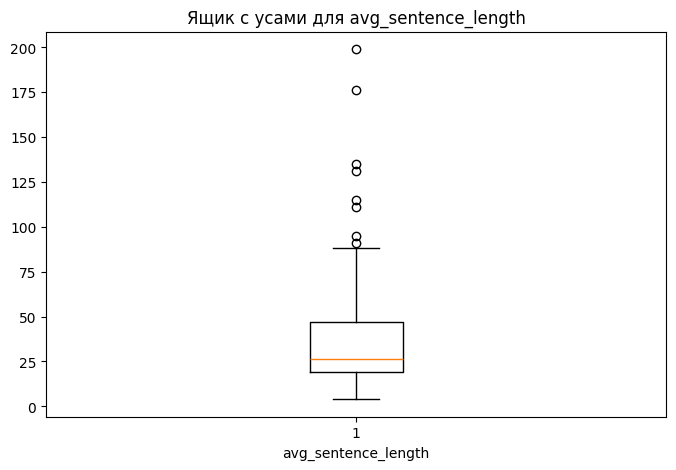

In [8]:
import matplotlib.pyplot as plt

feature = "avg_sentence_length"

plt.figure(figsize=(8,5))
plt.boxplot(df_clean[feature])
plt.title("Ящик с усами для avg_sentence_length")
plt.xlabel("avg_sentence_length")
plt.show()

In [9]:
feature = "avg_sentence_length"

Q1 = df_clean[feature].quantile(0.25)
Q3 = df_clean[feature].quantile(0.75)

IQR = Q3 - Q1 #интерквартильный размах, мера вариативности, устойчивая к выбросам
            
lower_bound = Q1 - 1.5 * IQR #находим усы до кружочков
upper_bound = Q3 + 1.5 * IQR

#Новый датафрейм без выбросов
df_final = df_clean[
    (df_clean[feature] >= lower_bound) &
    (df_clean[feature] <= upper_bound)
] #убираем выбросы, усы остаются

print("Размер до удаления:", df_clean.shape)
print("Размер после удаления:", df_final.shape)
print("Удалено строк:", df_clean.shape[0] - df_final.shape[0])

Размер до удаления: (135, 27)
Размер после удаления: (127, 27)
Удалено строк: 8


## ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ

In [10]:
#Расчет МЦТ целевого признака (среднее арифметическое, медиана)
target = "flesch_reading_ease"

mean_value = df_final[target].mean() 
#mean() - среднее арифметическое значений в столбце
median_value = df_final[target].median()

print("Среднее:", mean_value)
print("Медиана:", median_value)

Среднее: 29.601414500170016
Медиана: 44.37645161290325


### Интерпретация МЦТ целевого признака (меры центральной тенденции)

- **Среднее значение** ≈ 29.6  
  Указывает на высокую общую сложность текстов в корпусе. Значение значительно ниже 60–70, что соответствует уровню «очень сложный» или «колледж/высшее образование».

- **Медиана** ≈ 44.4  
  Типичный (срединный) текст в корпусе обладает умеренной сложностью — читаемость на уровне старших классов школы или начального вуза.

- Значительное расхождение между средним (29.6) и медианой (44.4)  
  Свидетельствует о существенной асимметрии распределения: в корпусе присутствуют фрагменты с экстремально низкой читаемостью, которые сильно тянут среднее вниз.

- **Вывод о характере корпуса**  
  Преобладание сложных текстов, особенно с очень высокой лингвистической сложностью, соответствует особенностям модернистской поэтики Мины Лой, где часто используются экспериментальные, плотные и синтаксически насыщенные конструкции.

In [11]:
#Расчет квартилей целевого признака (q0, q1, q3, q4)
q0 = df_final[target].min() #самая сложная читаемость
q1 = df_final[target].quantile(0.25)
q3 = df_final[target].quantile(0.75)
q4 = df_final[target].max() #самая легкая читаемость
#Q0 = 1 (минимум)
#Q1 = 3.5 (25% значений ≤ Q1)
#Q2 = 6.5 (медиана)
#Q3 = 8.5 (75% значений ≤ Q3)
#Q4 = 12 (максимум)

print("Q0 (минимум):", q0) #у Мины Лой очень много тире и дефисов, поэтому программа считывает 
#эти дефисы как очень сложные слова, отсюда и минусовые значения.
print("Q1 (25%):", q1)
print("Q3 (75%):", q3)
print("Q4 (максимум):", q4)

Q0 (минимум): -205.0357894736842
Q1 (25%): 18.159230769230785
Q3 (75%): 60.29198887678863
Q4 (максимум): 86.70500000000001


### Интерпретация квартилей целевого(q0, q1, q3, q4)

- **Q0 (минимум) ≈ –205**  
  Экстремально низкое значение указывает на наличие в корпусе фрагментов с предельно усложнённой синтаксической и стилистической структурой. Такие отрицательные значения читаемости характерны для крайне экспериментальных, почти недоступных текстов.

- **Q1 (первый квартиль) ≈ 18**  
  Нижняя четверть текстов обладает очень высокой лингвистической сложностью. Эти фрагменты требуют высокого уровня образования и значительных усилий для понимания - типично для авангардной и модернистской поэзии.

- **Q3 (третий квартиль) ≈ 60**  
  Верхняя четверть текстов достигает уровня стандартной / хорошей читабельности (примерно соответствует текстам для старших классов школы или неспециализированной взрослой аудитории). Это показывает наличие в корпусе относительно более доступных фрагментов.

- **Общий вывод по распределению квартилей**  
  Значительный разрыв между Q1 и Q3, а также экстремально низкое минимальное значение свидетельствуют о большой неоднородности корпуса.  
  Корпус охватывает широкий стилистический спектр: от радикально экспериментальных, трудно интерпретируемых текстов в духе модернистской поэтики Мины Лой до относительно понятных и традиционных фрагментов.

In [12]:
#Расчет мер вариативности целевого признака (размах, интерквартильный размах, дисперсия, стандартное отклонение)
data_range = q4 - q0
iqr = q3 - q1
variance = df_final[target].var() #мера, показывающая усредненный квадрат отклонений 
#количественного признака от среднего арифметического
std_dev = df_final[target].std() 
#вычисляет стандартное отклонение, на сколько отклоняется от нормы

print("Размах:", data_range)
print("Интерквартильный размах:", iqr)
print("Дисперсия:", variance)
print("Стандартное отклонение:", std_dev)

Размах: 291.74078947368423
Интерквартильный размах: 42.13275810755785
Дисперсия: 2498.1037382380955
Стандартное отклонение: 49.98103378520792


### Интерпретация мер вариативности целевого признака

- **Размах (range) ≈ 291.7**  
  Очень большая амплитуда значений (от экстремально низких до относительно высоких) свидетельствует о радикальной неоднородности корпуса по уровню читаемости - от практически недоступных текстов до достаточно понятных.

- **Стандартное отклонение ≈ 50**  
  Высокое значение стандартного отклонения подтверждает значительную разбросанность данных вокруг среднего. Большинство текстов отклоняется от средней читаемости на ±50 пунктов, что соответствует очень разным уровням сложности.

- **Интерквартильный размах (IQR) ≈ 42**  
  Центральные 50 % наблюдений охватывают диапазон в 42 пункта - это широкий интервал, который указывает на стилистическую неоднородность даже внутри основной массы текстов (без учета крайних выбросов).

- **Дисперсия ≈ 2498.10**
Высокое значение дисперсии (как квадрата стандартного отклонения) подчёркивает сильную разбросанность значений читаемости. Это количественно подтверждает, что тексты в корпусе значительно варьируются по сложности, с большими отклонениями от среднего, что типично для творчества с экспериментальными элементами.

- **Общий вывод**  
  Все меры вариативности (размах, дисперсия, стандартное отклонение, IQR) демонстрируют высокую гетерогенность корпуса по уровню читаемости.  
  Это отражает характер поэтики Мины Лой: сочетание радикально экспериментальных, синтаксически и лексически насыщенных фрагментов с более традиционными и относительно доступными текстами.

In [13]:
#Расчет описательных статистик для категориального признака (мода, количество уникальных значений)
cat_feature = "historical_period"

mode_value = df_final[cat_feature].mode()[0] 
#[0] - индекс, берёт первое значение из результата
unique_count = df_final[cat_feature].nunique()
#nunique() считает количество уникальных значений в столбце
print("Мода:", mode_value)
print("Количество уникальных значений:", unique_count)

Мода: Первая мировая война
Количество уникальных значений: 4


### Интерпретация описательных статистик для категориального признака

- **Количество уникальных значений**  
  В корпусе представлены четыре исторических периода XX века:  
  Первая мировая война, межвоенный период, Вторая мировая война, послевоенный период.

- **Мода (наиболее часто встречающееся значение)**  
  Наиболее частый период - Первая мировая война.  
  Это означает, что тексты, написанные в период Первой мировой войны, преобладают в собранном корпусе.

- **Характер распределения**  
  Распределение периодов неравномерное - один исторический период (Первая мировая война) представлен значительно чаще остальных.

- **Методологические следствия**  
  Неравномерность распределения необходимо учитывать при интерпретации результатов:  
  - средние значения читаемости, стилистических и тональных характеристик могут быть смещены в сторону особенностей текстов периода Первой мировой войны  
  - выводы о динамике языка и стиля Мины Лой в разные исторические эпохи следует делать с осторожностью  
  - для более сбалансированного сравнения периодов может потребоваться стратифицированная выборка или взвешивание наблюдений в дальнейшем анализе

## КОРРЕЛЯЦИЯ

In [14]:
#Парная корреляция между целевой и предиктором
target = "flesch_reading_ease"
predictor = "avg_sentence_length"
#корреляция показывает линейную взаимосвязь , а не влияние чего-то на что-то!!!!!
#!!!!!

correlation = df_final[target].corr(df_final[predictor])
#𝑟 = 1 r=1 → идеальная прямая положительная корреляция
#𝑟 = −1 r=−1 → идеальная прямая отрицательная корреляция
#𝑟 = 0 r=0 → корреляции нет

#Положительный (+) → при увеличении одной переменной другая тоже растёт
#Отрицательный (-) → при увеличении одной переменной другая уменьшается

print("Коэффициент корреляции Пирсона:", correlation)

Коэффициент корреляции Пирсона: -0.6128951710195932


### Интерпретация коэффициент корреляции между целевой и предиктором

Анализ коэффициента корреляции Пирсона между целевым признаком `flesch_reading_ease` и предиктором `avg_sentence_length` показывает значение -0.613, что указывает на достаточно сильную отрицательную связь. Это означает, что по мере увеличения средней длины предложения в тексте индекс Флеша снижается, то есть текст становится сложнее для восприятия. Напротив, более короткие предложения связаны с более высоким значением Flesch Reading Ease, что соответствует более лёгкой читаемости. Данный результат согласуется с теоретическими ожиданиями, так как длина предложения напрямую влияет на синтаксическую сложность текста. Это позволяет заключить, что `avg_sentence_length` является важным предиктором читаемости произведений в корпусе.


In [15]:
#Корреляционная матрица (Пирсон) только между количественными признаками
numeric_df = df_final.select_dtypes(include=["number"])
correlation_matrix = numeric_df.corr(method="pearson")

print(correlation_matrix)

                          year  word_count  sentence_count  \
year                  1.000000    0.230187        0.209844   
word_count            0.230187    1.000000        0.983018   
sentence_count        0.209844    0.983018        1.000000   
avg_sentence_length  -0.236979   -0.224338       -0.263760   
avg_word_length      -0.005444   -0.192787       -0.194071   
unique_words_ratio   -0.431541   -0.724655       -0.658853   
noun_ratio           -0.041623   -0.326773       -0.304243   
verb_ratio            0.030300    0.150850        0.152155   
adj_ratio            -0.035033   -0.153370       -0.145372   
adv_ratio             0.273716    0.405582        0.365471   
stopword_ratio        0.161221    0.383847        0.351566   
punctuation_ratio     0.191056    0.257565        0.269855   
long_words_ratio      0.039934   -0.034288       -0.043816   
rare_words_ratio     -0.408405   -0.664632       -0.601321   
flesch_reading_ease   0.271618    0.217403        0.248239   
flesch_k

In [20]:
#Находим самую сильную корреляцию

import numpy as np
#библиотека для работы с числами и массивами

# Убираем корреляцию переменной с самой собой
corr_matrix = correlation_matrix.copy() #Создание копии корреляционной матрицы
#создаёт отдельный объект, который можно изменять, не трогая оригинал.
np.fill_diagonal(corr_matrix.values, 0)
#fill_diagonal(..., 0) заменяет все значения на главной диагонали на 0.
#corr_matrix.values берёт все числа из таблицы в виде массива NumPy
max_corr = corr_matrix.abs().max().max()
#берёт модуль каждого элемента, чтобы отрицательная корреляция тоже считалась “сильной”
#возвращает максимум по каждому столбцу
#максимум среди этих максимумов, то есть единственное число
#возвращает индексы, где условие True

print("Самая сильная корреляция по модулю:", max_corr)

Самая сильная корреляция по модулю: 0.9979236407464552


In [17]:
#Находим пару признаков с самой сильной корреляцией
strong_pair = np.where(corr_matrix.abs() == max_corr)
#corr_matrix.abs() == max_cor - переделываем таблицу в таблицу (True/False),
#где True = 0.997, а False != максимальной корреляции.
#np.where(...) возвращает индексы, где условие True

feature1 = corr_matrix.columns[strong_pair[0][0]] 
#у нас есть два списка - вертикаль(0) и горизониаль(1)
#В этих списках одно значение, т.к. True только одно.
feature2 = corr_matrix.columns[strong_pair[1][0]]
#в нулевом списке(то есть в первом) выведи нулевое значение(то есть первое)

print("Самая сильная корреляция между:", feature1, "и", feature2)

Самая сильная корреляция между: flesch_kincaid_grade и gunning_fog


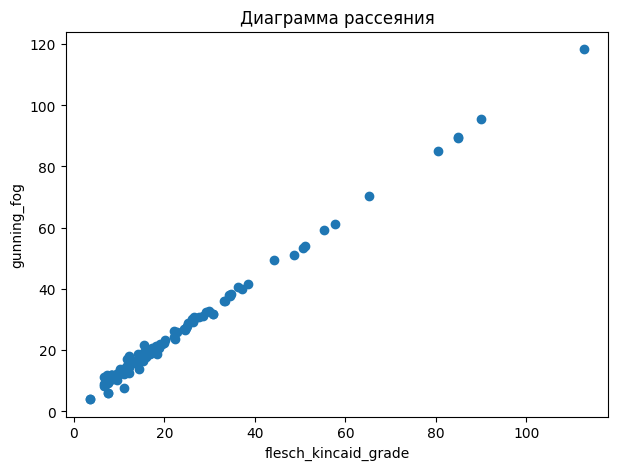

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(df_final[feature1], df_final[feature2])
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("Диаграмма рассеяния")
plt.show()

### Интерпретация

Между признаками `flesch_kincaid_grade` и `gunning_fog` наблюдается почти идеальная положительная линейная связь (r ≈ 0.998).  
Оба показателя измеряют сложность текста с точки зрения необходимого уровня образования и плотности сложных конструкций.

## ЛИНЕЙНАЯ РЕГРЕССИЯ

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = df_final[["avg_sentence_length"]]  # предиктор(ы)
y = df_final["flesch_reading_ease"] #целевая переменная  

model = LinearRegression()

model.fit(X, y)
#fit() "подгоняет" (обучает) модель под данные

y_pred = model.predict(X)
#Метод predict() использует обученную модель, чтобы сделать предсказания 
#для входных данных X

print("Модель обучена.")

Модель обучена.


In [28]:
w0 = model.intercept_
#w0 точка пересечения с осью Y, свободный коэффициент.
#Это значение читаемости (y) в том случае, если бы длина предложения 
#(x) вдруг стала равна нулю
w1 = model.coef_[0]
#w1 коэффициент наклона. 
#Он показывает, как сильно меняется читаемость текста (y), 
#когда длина предложения (x) меняется на единицу.

#читаемость = w1 * длина предложения + w0

print("w0 (свободный член):", w0)
print("w1 (коэффициент наклона):", w1)

w0 (свободный член): 79.30653230978066
w1 (коэффициент наклона): -1.534765629749542


In [27]:
#y = правильные ответы (реальные значения из учебника)
#y_pred = ответы, которые дал ученик (предсказания модели)

r2 = r2_score(y, y_pred) #r2_score — это функция из библиотеки scikit-learn
#Коэффициент детерминации насколько точно построенная модель
#объясняет поведение переменной. От 0 до 1, чем ближе к 1, тем лучше. У нас плохо работает
#Функция запускает алгоритм сравнения. Она смотрит на каждую пару 
#"правильный ответ — предсказание"
#Считает среднее правильных значений (y).
#Сравнивает ошибки твоей модели (y_pred) с ошибками этого среднего.
#Возвращает результат сравнения в виде понятной оценки от 0 до 1.
                 #"Насколько моя модель лучше, чем просто среднее значение?"
mse = mean_squared_error(y, y_pred)
#среднеквадратичная ошибка
#Принцип тот же
           #"Как сильно я ошибся в среднем, если крупные ошибки считать особенно строго?"
mae = mean_absolute_error(y, y_pred)
#средняя абсолютная ошибка
            #все ошибки одинакого серьезны + не возводим в квадрат, только модуль
print("R2:", r2)
print("MSE:", mse)
print("MAE:", mae)

R2: 0.37564049065913685
MSE: 1547.4336052000242
MAE: 24.477971478260702


### Словесное описание модели однофакторной линейной регрессии

Была построена однофакторная линейная регрессия для предсказания читаемости текста (flesch_reading_ease) на основе одного предиктора — средней длины предложения (avg_sentence_length). Модель оценивает, как изменение средней длины предложения влияет на удобочитаемость текста, предполагая линейную зависимость между этими величинами.


### Уравнение обученной модели

Модель однофакторной линейной регрессии:
$$
\hat{y} = w_0 + w_1 x
$$

#читаемость = w1 * длина предложения + w0

В нашем случае:
$$
\hat{flesch\_reading\_ease} = 79.31 - 1.53 \cdot avg\_sentence\_length
$$
#читаемость = w1 * длина предложения + w0

### Интерпретация параметров обученной модели (w0, w1)

- Свободный член (w0 = 79.31) - это прогнозируемое значение индекса Flesch Reading Ease, когда средняя длина предложения равна нулю. В контексте текста это теоретическое значение максимально лёгкой читаемости.

- Коэффициент наклона (w1 = –1.53) - показывает, что при увеличении средней длины предложения на одно слово ожидаемое значение Flesch Reading Ease уменьшается примерно на 1.53 пункта. Иначе говоря, более длинные предложения делают текст сложнее для восприятия.

### Интерпретация метрик качества обученной модели (R2, MSE, MAE)

- R² = 0.376 означает, что примерно 37.6 % вариации индекса Flesch Reading Ease объясняется линейной зависимостью от средней длины предложения. Остальные 62.4 % вариации обусловлены другими факторами (лексическое разнообразие, доля сложных слов, синтаксическая структура и т.д.).

- MSE = 1547.43 - среднеквадратичная ошибка показывает, насколько в среднем предсказанные значения отклоняются от фактических в квадратичном измерении. Высокое значение обусловлено наличием экстремально сложных текстов с низким Flesch Reading Ease.

Хорошая модель: MSE = 50-100

Плохая модель: MSE = 1000-2000

Ужасная модель: MSE = 5000+ (если предсказывает всё невпопад)

- MAE = 24.48 пункта означает, что в среднем прогноз отклоняется почти на четверть всего диапазона шкалы - это довольно большая ошибка, что согласуется с умеренным R² и высокой вариабельностью признака.

## ФИЛЬТРАЦИЯ И СОРТИРОВКА

In [6]:
#Сортировка по возрастанию данных отфильтрованных по одному условию
df_prose_sorted_asc = (df[df["form"] == "проза"].sort_values(by="avg_sentence_length", ascending=True))
#смотрим только колонки с прозой
df_prose_sorted_asc

,title,year,form,text,word_count,sentence_count,avg_sentence_length,avg_word_length,unique_words_ratio,noun_ratio,...,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,historical_period,country_where_written,source
13,"Insel, 14",1936.0,проза,"“BREAKFAST,” I ANNOUNCED.\r\nThis time Insel d...",753,53,14.207547,4.634794,0.568393,0.183267,...,65.176702,7.419841,9.417393,0.055,0.863,0.082,0.9768,межвоенный,Франция,Insel
24,"Insel, 25",1936.0,проза,"INTIMATELY CONFIDENTIAL ONCE MORE, INSEL was t...",573,39,14.692308,4.425829,0.544503,0.171030,...,66.567578,7.808333,10.586283,0.055,0.885,0.060,0.6464,межвоенный,Франция,Insel
16,"Insel, 17",1936.0,проза,BEFORE I LEFT MLLE ALPHA TOLD ME THAT STIFF Us...,363,24,15.125000,4.154270,0.589532,0.176309,...,73.865478,6.888218,8.638127,0.075,0.875,0.050,-0.8082,межвоенный,Франция,Insel
39,THE THREE WISHES,NaN,проза,The babies were all born in the same quarter o...,7412,475,15.604211,4.351322,0.309903,0.209120,...,72.425838,6.691850,8.995386,0.071,0.814,0.115,0.9999,NaN,NaN,Stories and Essays
15,"Insel, 16",1936.0,проза,ON MY WAY TO THE STATION I CALLED ON MLLE Alph...,598,37,16.162162,4.260870,0.553512,0.162207,...,70.596644,7.132721,9.996678,0.094,0.816,0.089,-0.7477,межвоенный,Франция,Insel
5,"Insel, 6",1936.0,проза,"“I’M SO UGLY NAKED,” HE TOLD ME MOST unexpecte...",667,41,16.268293,4.349325,0.550225,0.148426,...,63.856177,8.569577,10.535967,0.102,0.829,0.069,-0.9647,межвоенный,Франция,Insel
3,"Insel, 4",1936.0,проза,I THOUGHT I HAD DROPPED INSEL. I WAS MISTAKEN....,3046,182,16.736264,4.358175,0.391989,0.168746,...,66.878700,7.801471,10.063263,0.103,0.816,0.081,-0.9970,межвоенный,Франция,Insel
1,"Insel, 2",1936.0,проза,"ON THE GROUNDS THAT HE WAS STARVING TO death, ...",1173,70,16.757143,4.510656,0.495311,0.175618,...,61.258746,8.597062,11.131213,0.069,0.839,0.092,0.9890,межвоенный,Франция,Insel
2,"Insel, 3",1936.0,проза,AT LAST THE BIOGRAPHY ABORTED AS HAD THE Quake...,235,14,16.785714,4.374468,0.685106,0.157447,...,61.637500,8.832173,11.480243,0.135,0.806,0.058,-0.9675,межвоенный,Франция,Insel
12,"Insel, 13",1936.0,проза,I WAS READY TO LEAVE FOR SAINT-CLOUD WITH my l...,3679,217,16.953917,4.455015,0.399293,0.177494,...,64.792009,8.275382,10.797538,0.098,0.821,0.080,-0.9956,межвоенный,Франция,Insel


### Интерпретация

В отфильтрованной прозе средняя длина предложений варьируется от примерно 14 до 31 слова, при этом тексты с более длинными предложениями чаще относятся к неопределённым источникам и периодам, тогда как короткие предложения встречаются преимущественно у произведений 1936 года во Франции.

In [7]:
#Сортировка по убыванию данных, отфильтрованных по одному условию
df_lyrics_sorted_desc = (df[df["form"] == "лирика"].sort_values(by="sentiment_compound", ascending=False))
df_lyrics_sorted_desc

,title,year,form,text,word_count,sentence_count,avg_sentence_length,avg_word_length,unique_words_ratio,noun_ratio,...,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,historical_period,country_where_written,source
52,The Effectual Marriage or THE INSIPID NARRATIV...,1915.0,лирика,The door was an absurd thing\r\nYet it was pas...,641,16,40.062500,4.616225,0.555382,0.185647,...,-136.575189,84.975535,89.139623,0.051,0.818,0.131,0.9958,Первая мировая война,Италия,Lunar Baedecker
44,Three Moments in Paris,1915.0,лирика,I. One O’Clock at Night\r\nThough you had neve...,605,16,37.812500,4.588430,0.591736,0.239669,...,-123.858068,80.551854,84.904194,0.070,0.821,0.109,0.9850,Первая мировая война,Италия,Rogue
32,LADY ASTERISK,NaN,лирика,The Russian ambassador—and King Edward’s mistr...,838,28,29.928571,4.437947,0.521480,0.187351,...,36.771794,18.682048,21.202609,0.091,0.792,0.117,0.9798,NaN,NaN,Stories and Essays
45,Sketch of a Man on a Platform,1915.0,лирика,Man of absolute physical equilibrium\r\nYou st...,227,3,75.666667,4.828194,0.696035,0.242291,...,-154.922027,90.018829,95.646847,0.012,0.872,0.117,0.9756,Первая мировая война,Италия,Rogue
68,"Songs to Joannes, 12",1917.0,лирика,Voices break on the confines of passion\nDesir...,83,1,83.000000,4.542169,0.807229,0.265060,...,-3.800361,34.408916,37.537349,0.026,0.708,0.266,0.9686,Первая мировая война,Италия,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Der Blinde Junge,1923.0,лирика,The dam Bellona\nlittered\nher eyeless offspri...,108,2,54.000000,5.537037,0.805556,0.305556,...,15.749322,24.353505,27.007477,0.148,0.806,0.047,-0.9041,межвоенный,Австрия,Lunar Baedecker
35,NEW YORK CAMELIO,NaN,лирика,Camelio has disappeared———\r\nhe is sitting up...,213,4,53.250000,4.586854,0.610329,0.248826,...,26.884543,22.241402,23.621951,0.107,0.837,0.056,-0.9042,NaN,NaN,Stories and Essays
54,The Black Virginity,1917.0,лирика,Baby Priests\r\nOn green sward\r\nYew-closed\r...,244,3,81.333333,4.950820,0.778689,0.245902,...,-54.907500,50.729167,53.500000,0.104,0.853,0.043,-0.9140,Первая мировая война,Америка,Lunar Baedecker
123,Hot Cross Bum,1949.0,лирика,Beyond a hell-vermilion\ncurtain of neon\nlies...,1168,22,53.090909,5.161815,0.665240,0.323630,...,-19.128071,34.625647,38.220041,0.113,0.785,0.102,-0.9182,послевоенный,Америка,The Last Lunar Baedeker


### Интерпретация

В лирике значения sentiment_compound варьируются от почти +1 до -0, при этом наиболее позитивные тексты сосредоточены в Италии времён Первой мировой войны, а негативные — в послевоенной Америке и неопределённых источниках.

In [8]:
#Сортировка по возрастанию данных, отфильтрованных по нескольким условиям
df_interwar_uk_sorted_asc = (df[(df["historical_period"] == "межвоенный") & (df["country_where_written"] == "Америка")].sort_values(by="flesch_reading_ease", ascending=True))
df_interwar_uk_sorted_asc

,title,year,form,text,word_count,sentence_count,avg_sentence_length,avg_word_length,unique_words_ratio,noun_ratio,...,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,historical_period,country_where_written,source
92,The Dead,1920.0,лирика,We have flowed out of ourselves\nBeginning on ...,212,3,70.666667,4.933962,0.707547,0.216981,...,-143.793654,84.988654,89.546154,0.115,0.822,0.063,-0.8981,межвоенный,Америка,Lunar Baedecker
96,Apology of Genius,1922.0,лирика,Ostracized as we are with God—\n The ...,162,4,40.500000,4.611111,0.709877,0.234568,...,-83.972778,65.217160,70.232099,0.093,0.824,0.083,-0.5859,межвоенный,Америка,Dial
94,Perlun,1920.0,лирика,the whipper snapper child of the sun...,126,2,63.000000,4.579365,0.777778,0.301587,...,-47.955200,51.001600,54.160000,0.108,0.803,0.089,-0.5719,межвоенный,Америка,Lunar Baedecker
97,Brancusi’s Golden Bird,1922.0,лирика,The toy\n become the aestheti...,104,2,52.000000,5.163462,0.778846,0.298077,...,-36.200000,44.145000,49.292308,0.038,0.887,0.075,0.6249,межвоенный,Америка,Dial
91,O Hell,1920.0,лирика,To clear the drifts of spring\nOf our forebear...,48,2,24.000000,5.041667,0.833333,0.291667,...,17.115000,22.796667,25.866667,0.061,0.888,0.051,-0.1280,межвоенный,Америка,Lunar Baedecker
95,Poe,1921.0,лирика,a lyric elixir of death\n embalms\n the ...,39,1,39.000000,4.846154,0.948718,0.461538,...,43.603846,16.866154,18.676923,0.089,0.826,0.085,-0.0516,межвоенный,Америка,Lunar Baedecker
26,VISITATION,1938.0,проза,"In the organic continuity of family life, one ...",2390,135,17.703704,4.735146,0.471967,0.232218,...,48.977736,11.820132,14.901806,0.076,0.842,0.082,0.9551,межвоенный,Америка,Insel


### Интерпретация

Наименьшие значения индекса Флеша соответствуют наиболее сложным для восприятия текстам. Это может свидетельствовать об усложнении литературного языка и синтаксиса в межвоенный период в американской литературе.

In [3]:
#Сортировка по убыванию данных, отфильтрованных по нескольким условиям
df_mw_prose_sorted_desc = (df[(df["historical_period"] == "межвоенный") & (df["form"] == "проза")].sort_values(by="rare_words_ratio", ascending=False))
df_mw_prose_sorted_desc

,title,year,form,text,word_count,sentence_count,avg_sentence_length,avg_word_length,unique_words_ratio,noun_ratio,...,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,historical_period,country_where_written,source
2,"Insel, 3",1936.0,проза,AT LAST THE BIOGRAPHY ABORTED AS HAD THE Quake...,235,14,16.785714,4.374468,0.685106,0.157447,...,61.637500,8.832173,11.480243,0.135,0.806,0.058,-0.9675,межвоенный,Франция,Insel
25,"Insel, 26",1936.0,проза,"“HOW GOES THE BOOK,” HE ASKED WITH HIS FORMER ...",404,19,21.263158,4.391089,0.633663,0.155941,...,64.572556,8.972882,12.011028,0.059,0.836,0.105,0.9508,межвоенный,Франция,Insel
21,"Insel, 22",1936.0,проза,I COULD NOT MAKE OUT WHY THIS FANTASTICALLY be...,506,25,20.240000,4.584980,0.592885,0.183794,...,57.019324,10.502560,12.988181,0.083,0.797,0.120,0.9808,межвоенный,Франция,Insel
13,"Insel, 14",1936.0,проза,"“BREAKFAST,” I ANNOUNCED.\r\nThis time Insel d...",753,53,14.207547,4.634794,0.568393,0.183267,...,65.176702,7.419841,9.417393,0.055,0.863,0.082,0.9768,межвоенный,Франция,Insel
19,"Insel, 20",1936.0,проза,EVERY NOW AND THEN THE SHARP OF HIS FLICKERING...,947,46,20.586957,4.463569,0.549102,0.184794,...,59.591809,9.926596,12.560546,0.072,0.835,0.093,0.9817,межвоенный,Франция,Insel
16,"Insel, 17",1936.0,проза,BEFORE I LEFT MLLE ALPHA TOLD ME THAT STIFF Us...,363,24,15.125000,4.154270,0.589532,0.176309,...,73.865478,6.888218,8.638127,0.075,0.875,0.050,-0.8082,межвоенный,Франция,Insel
4,"Insel, 5",1936.0,проза,"“FLEISCH OHNE KNOCHEN,” INSEL ESPECIALLY hollo...",1123,49,22.918367,4.530721,0.519145,0.181656,...,53.732629,11.647688,14.431909,0.083,0.838,0.079,-0.7176,межвоенный,Франция,Insel
11,"Insel, 12",1936.0,проза,HIS EYES NOW PACIFIED IN A STEADY HUMAN mesmer...,842,43,19.581395,4.423990,0.529691,0.175772,...,63.078318,9.115051,11.811246,0.085,0.822,0.093,0.6026,межвоенный,Франция,Insel
5,"Insel, 6",1936.0,проза,"“I’M SO UGLY NAKED,” HE TOLD ME MOST unexpecte...",667,41,16.268293,4.349325,0.550225,0.148426,...,63.856177,8.569577,10.535967,0.102,0.829,0.069,-0.9647,межвоенный,Франция,Insel
15,"Insel, 16",1936.0,проза,ON MY WAY TO THE STATION I CALLED ON MLLE Alph...,598,37,16.162162,4.260870,0.553512,0.162207,...,70.596644,7.132721,9.996678,0.094,0.816,0.089,-0.7477,межвоенный,Франция,Insel


### Интерпретация

В межвоенной прозе США тексты с самым высоким коэффициентом редких слов встречаются реже, а в большинстве случаев редкие слова преобладают в французских произведениях 1936 года.

## НОВЫЕ ПРИЗНАКИ

In [4]:
#Приведение признака к бинарному виду с помощью анонимной функции
df["is_prose"] = df["form"].apply(lambda x: 1 if x == "проза" else 0)
df[["form", "is_prose"]]
#используются двойные скобки [["form", "is_prose"]], потому что мы выбираем 
#несколько колонок, и результат должен быть датафреймом (таблицей)

,form,is_prose
0,проза,1
1,проза,1
2,проза,1
3,проза,1
4,проза,1
...,...,...
132,лирика,0
133,лирика,0
134,лирика,0
135,лирика,0


### Интерпретация

Созданный бинарный признак позволяет формально разделить тексты на прозаические и лирические. Это упрощает последующий анализ.

In [44]:
#Создание нового признака с использованием in / count() / len() в анонимной функции
war_words = ["war", "battle", "soldier", "army", "death"]
df["war_lexicon_count"] = df["text"].apply(lambda x: sum(x.lower().count(word) for word in war_words))
df[["war_lexicon_count"]]

,war_lexicon_count
0,7
1,6
2,0
3,6
4,4


### Интерпретация

Новый признак отражает степень тематической связанности текста с военной лексикой. Его значения могут быть полезны при анализе текстов военных и послевоенных периодов и сопоставлении тематического наполнения произведений.

In [45]:
#Создание нового признака с использованием именованной функции
def text_length_chars(text):
#считает длину каждого текста в символах
    return len(text)
df["text_length_chars"] = df["text"].apply(text_length_chars)
#обращаемся к датафрейму только когда пишем кавычки!
df[["text_length_chars"]]

,text_length_chars
0,14507
1,6807
2,1331
3,17162
4,6398


### Интерпретация

Признак длины текста в символах позволяет дополнительно оценить объём текстовых фрагментов и сопоставить его с другими метриками, такими как количество слов и предложений, а также показателями читаемости.

## ЧАСТОТНЫЕ ТАБЛИЦЫ

In [46]:
#Частотная таблица категориального признака, упорядоченная по убыванию значений
freq_desc = df["historical_period"].value_counts()
#value_counts() считает, сколько раз каждое уникальное значение встречается 
#в колонке, и возвращает результат, отсортированный от самого частого к самому редкому.
freq_desc

historical_period
Первая мировая война    62
межвоенный              47
Вторая мировая война     7
послевоенный             7
Name: count, dtype: int64

### Интерпретация

Большинство произведений в датасете относятся к периоду Первой мировой войны и межвоенному времени, тогда как тексты Второй мировой войны и послевоенные встречаются значительно реже.

In [47]:
#Частотная таблица категориального признака, упорядоченная по возрастанию значений
freq_asc = df["historical_period"].value_counts(ascending=True)
freq_asc

historical_period
послевоенный             7
Вторая мировая война     7
межвоенный              47
Первая мировая война    62
Name: count, dtype: int64

### Интерпретация

Во время второй мировой войны и после нее Мина Лой стала писать меньше произведений, что отчетливо видно по таблице.

In [48]:
#Частотная таблица категориального признака, упорядоченная по возрастанию индексов
freq_index_asc = df["historical_period"].value_counts().sort_index()
#Сортировка по названию периода (по алфавиту) и регистру
freq_index_asc

historical_period
Вторая мировая война     7
Первая мировая война    62
межвоенный              47
послевоенный             7
Name: count, dtype: int64

### Интерпретация

Упорядочивание по индексам позволяет рассмотреть категории без учёта их частоты. Такой подход удобен для обзора всех возможных значений признака и проверки корректности категоризации данных.

In [49]:
#Частотная таблица категориального признака, упорядоченная по убыванию индексов
freq_index_desc = df["historical_period"].value_counts().sort_index(ascending=False)
freq_index_desc

historical_period
послевоенный             7
межвоенный              47
Первая мировая война    62
Вторая мировая война     7
Name: count, dtype: int64

### Интерпретация

Обратная сортировка по индексам даёт альтернативный способ представления категорий и может быть полезна при сравнении периодов в заданном хронологическом порядке.

## ВИЗУАЛИЗАЦИЯ

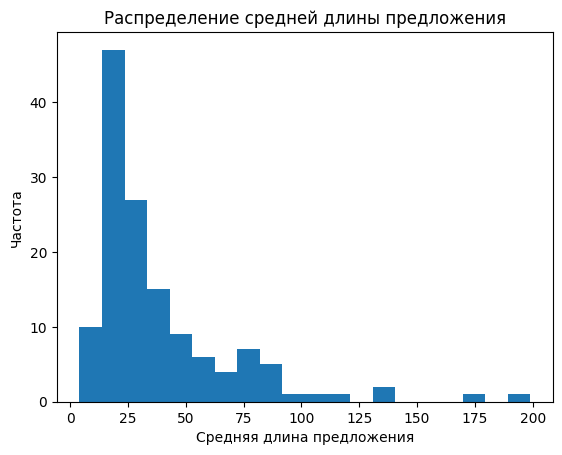

In [50]:
#Гистограмма количественного признака
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df["avg_sentence_length"].dropna(), bins=20)
#dropna() удаляет пустые значения (NaN).+ 20 интервалов
plt.xlabel("Средняя длина предложения")
plt.ylabel("Частота")
plt.title("Распределение средней длины предложения")
plt.show()

### Интерпретация

Основная масса текстов сосредоточена в диапазоне небольших и средних значений средней длины предложения, что свидетельствует о преобладании текстов с относительно простой или умеренно сложной синтаксической структурой.

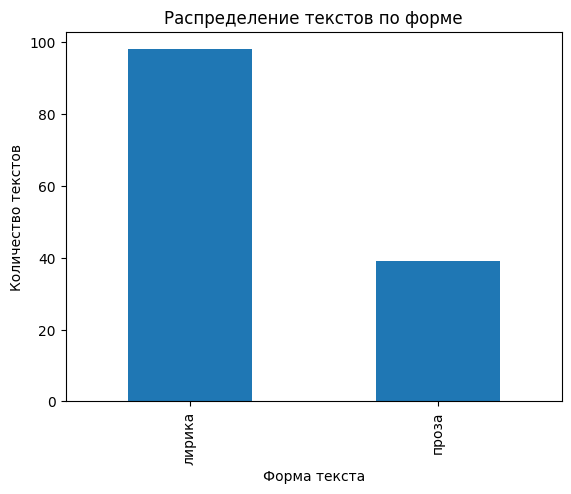

In [51]:
#Столбчатая диаграмма категориального признака 
plt.figure()
df["form"].value_counts().plot(kind="bar")
#value_counts() считает, сколько раз встречается каждая форма по убыванию
plt.xlabel("Форма текста")
plt.ylabel("Количество текстов")
plt.title("Распределение текстов по форме")
plt.show()

### Интерпретация

В датасете количественно преобладают лирические тексты по сравнению с прозаическими.

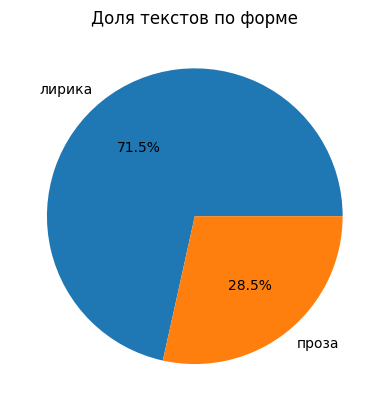

In [52]:
#Круговая диаграмма категориального признака
plt.figure()
df["form"].value_counts().plot(kind="pie", autopct="%1.1f%%")
#automatic percentage="%1.1f%%" добавляет подписи с процентами на каждый кусочек.
# %1.1f — число с одним знаком после запятой (например, 45.5)
# %% — просто значок процента (первый % экранирует второй)
plt.title("Доля текстов по форме")
plt.ylabel("")
plt.show()

### Интерпретация

Круговая диаграмма подтверждает вывод из столбчатой диаграммы в относительных величинах: лирика составляет около 70 % всех текстов, тогда как проза — около 30 %.

## СВОДНЫЕ ТАБЛИЦЫ

In [53]:
#Сводная таблица: один столбец группировки, один столбец агрегирования, один метод агрегирования
pivot_1 = df.groupby("form")["avg_sentence_length"].mean()
#группируем лирику/прозу и делаем из них столбцы (2)
#потом смотрим на среднюю длину, а затем mean() высчитывает среднее из всех чисел
#в новом столбце
pivot_1

form
лирика    45.075953
проза     22.141859
Name: avg_sentence_length, dtype: float64

### Интерпретация

В среднем лирические тексты содержат почти в два раза более длинные предложения, чем прозаические.

In [54]:
#Сводная таблица: несколько столбцов группировки, один столбец агрегирования, один метод агрегирования
pivot_2 = (df.groupby(["form", "historical_period"])["flesch_reading_ease"].mean())
pivot_2

form    historical_period   
лирика  Вторая мировая война    37.190462
        Первая мировая война   -11.376033
        межвоенный             -16.612934
        послевоенный            29.492296
проза   межвоенный              61.717321
Name: flesch_reading_ease, dtype: float64

### Интерпретация

Лирика заметно сложнее для чтения в период Первой мировой войны и межвоенного времени, тогда как проза межвоенного периода остаётся относительно легко читаемой.

In [55]:
#Сводная таблица: один столбец группировки, несколько столбцов агрегирования, один метод агрегирования
pivot_3 = (df.groupby("country_where_written")[["avg_sentence_length", "rare_words_ratio"]].mean())
pivot_3

,avg_sentence_length,rare_words_ratio
country_where_written,,
Австрия,54.000000,0.750000
Америка,43.355678,0.670196
Италия,39.352593,0.768762
Мексика,19.333333,0.793103
Франция,37.190020,0.474833


### Интерпретация

Тексты из Австрии и Италии отличаются более длинными предложениями, тогда как тексты из Мексики содержат наибольшую долю редких слов.

In [56]:
#Сводная таблица: один столбец группировки, один столбец агрегирования, несколько методов агрегирования
pivot_4 = (df.groupby("form")["word_count"].agg(["mean", "min", "max"]))
#agg — сокращение от aggregate (собрать),передаем список функций ["mean", "min", "max"].
pivot_4

,mean,min,max
form,,,
лирика,144.581633,4,1168
проза,1910.666667,235,8602


### Интерпретация

Проза в среднем значительно длиннее лирики, с максимальным количеством слов до 8602, тогда как лирика редко превышает 1168 слов.